In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv('../data/processed/orders_clean.csv', 
                     parse_dates=['order_purchase_timestamp',
                                  'order_approved_at',
                                  'order_delivered_carrier_date',
                                  'order_delivered_customer_date',
                                  'order_estimated_delivery_date'])

order_items = pd.read_csv('../data/processed/order_items_clean.csv',
                          parse_dates=['shipping_limit_date'])

customers = pd.read_csv('../data/processed/customers_clean.csv')
products = pd.read_csv('../data/processed/products_clean.csv')
sellers = pd.read_csv('../data/processed/sellers_clean.csv')
payments = pd.read_csv('../data/processed/payments_clean.csv')
reviews = pd.read_csv('../data/processed/reviews_clean.csv')
geolocation = pd.read_csv('../data/processed/geolocation_clean.csv')
translation = pd.read_csv('../data/processed/translation_clean.csv')

print("All datasets loaded from processed folder")

All datasets loaded from processed folder


In [3]:
seller_df = sellers[['seller_id']].copy()
print("Seller dataframe created with seller_id column only")
print("Number of unique sellers:", seller_df['seller_id'].nunique())

Seller dataframe created with seller_id column only
Number of unique sellers: 3095


In [4]:
seller_df= seller_df.merge(order_items[['order_id', 'seller_id', 'price']], on='seller_id', how='left')
print("Seller dataframe merged with order_items dataframe on seller_id")
print("Seller dataframe shape after merge:", seller_df.shape)
display(seller_df.head())

Seller dataframe merged with order_items dataframe on seller_id
Seller dataframe shape after merge: (112650, 3)


,seller_id,order_id,price
0,3442f8959a84dea7ee197c632cb2df15,4a90af3e85dd563884e2afeab1091394,106.20
1,3442f8959a84dea7ee197c632cb2df15,6d953888a914b67350d5bc4d48f2acab,101.70
2,3442f8959a84dea7ee197c632cb2df15,bc8a5de6abf5b14f98a6135a7fb46731,10.80
3,d1b65fc7debc3361ea86b5f14c68d2e2,035201c3c82a97f8a25dd6bd5244b2d5,89.99
4,d1b65fc7debc3361ea86b5f14c68d2e2,0504447548229e075dea8441b37b1e2a,199.90


In [5]:
seller_df = seller_df.merge(orders[['order_id', 'order_status']], on='order_id', how='left')
print("Seller dataframe merged with orders dataframe on order_id")
print("Seller dataframe shape after merge:", seller_df.shape)
display(seller_df.head())

Seller dataframe merged with orders dataframe on order_id
Seller dataframe shape after merge: (112650, 4)


,seller_id,order_id,price,order_status
0,3442f8959a84dea7ee197c632cb2df15,4a90af3e85dd563884e2afeab1091394,106.20,delivered
1,3442f8959a84dea7ee197c632cb2df15,6d953888a914b67350d5bc4d48f2acab,101.70,delivered
2,3442f8959a84dea7ee197c632cb2df15,bc8a5de6abf5b14f98a6135a7fb46731,10.80,delivered
3,d1b65fc7debc3361ea86b5f14c68d2e2,035201c3c82a97f8a25dd6bd5244b2d5,89.99,delivered
4,d1b65fc7debc3361ea86b5f14c68d2e2,0504447548229e075dea8441b37b1e2a,199.90,delivered


In [6]:
seller_df = seller_df[seller_df['order_status'] == 'delivered'].copy()
print("Filtered seller dataframe to include only delivered orders")
print("Seller dataframe shape after filtering:", seller_df.shape)
display(seller_df.head())

Filtered seller dataframe to include only delivered orders
Seller dataframe shape after filtering: (110197, 4)


,seller_id,order_id,price,order_status
0,3442f8959a84dea7ee197c632cb2df15,4a90af3e85dd563884e2afeab1091394,106.20,delivered
1,3442f8959a84dea7ee197c632cb2df15,6d953888a914b67350d5bc4d48f2acab,101.70,delivered
2,3442f8959a84dea7ee197c632cb2df15,bc8a5de6abf5b14f98a6135a7fb46731,10.80,delivered
3,d1b65fc7debc3361ea86b5f14c68d2e2,035201c3c82a97f8a25dd6bd5244b2d5,89.99,delivered
4,d1b65fc7debc3361ea86b5f14c68d2e2,0504447548229e075dea8441b37b1e2a,199.90,delivered


In [7]:
seller_df = seller_df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
print("Seller dataframe merged with reviews dataframe on order_id")
print("Seller dataframe shape after merge:", seller_df.shape)
display(seller_df.head())

Seller dataframe merged with reviews dataframe on order_id
Seller dataframe shape after merge: (110840, 5)


,seller_id,order_id,price,order_status,review_score
0,3442f8959a84dea7ee197c632cb2df15,4a90af3e85dd563884e2afeab1091394,106.20,delivered,5.0
1,3442f8959a84dea7ee197c632cb2df15,6d953888a914b67350d5bc4d48f2acab,101.70,delivered,1.0
2,3442f8959a84dea7ee197c632cb2df15,bc8a5de6abf5b14f98a6135a7fb46731,10.80,delivered,3.0
3,d1b65fc7debc3361ea86b5f14c68d2e2,035201c3c82a97f8a25dd6bd5244b2d5,89.99,delivered,5.0
4,d1b65fc7debc3361ea86b5f14c68d2e2,0504447548229e075dea8441b37b1e2a,199.90,delivered,5.0


In [8]:
sellers_df = seller_df.groupby('seller_id').agg(
    total_orders = ('order_id', 'count'),
    average_review_score = ('review_score', 'mean'),
    total_revenue = ('price', 'sum')
).reset_index()

print("Aggregated seller dataframe created with total_orders, average_review_score, and total_revenue")
print("Aggregated seller dataframe shape:", sellers_df.shape)
print("The first 10 sellers with the highest total revenue:")
display(sellers_df.sort_values(by='total_revenue', ascending=False).head(10))

Aggregated seller dataframe created with total_orders, average_review_score, and total_revenue
Aggregated seller dataframe shape: (2970, 4)
The first 10 sellers with the highest total revenue:


,seller_id,total_orders,average_review_score,total_revenue
834,4869f7a5dfa277a7dca6462dcf3b52b2,1148,4.139474,226987.93
982,53243585a1d6dc2643021fd1853d8905,400,4.128141,217940.44
858,4a3ca9315b744ce9f8e9374361493884,1971,3.828630,199408.32
2903,fa1c13f2614d7b5c4749cbc52fecda94,579,4.373913,190917.14
1480,7c67e1448b00f6e969d365cea6b010ab,1366,3.354197,188063.83
1504,7e93a43ef30c4f03f38b393420bc753a,322,4.364486,165981.49
2543,da8622b14eb17ae2831f4ac5b9dab84a,1571,4.075399,162303.67
1450,7a67c85e85bb2ce8582c35f2203ad736,1159,4.268462,140238.65
188,1025f0e2d44d7041d6cf58b6550e0bfa,1434,3.867792,139720.16
1758,955fee9216a65b617aa5c0531780ce60,1474,4.089481,131906.71


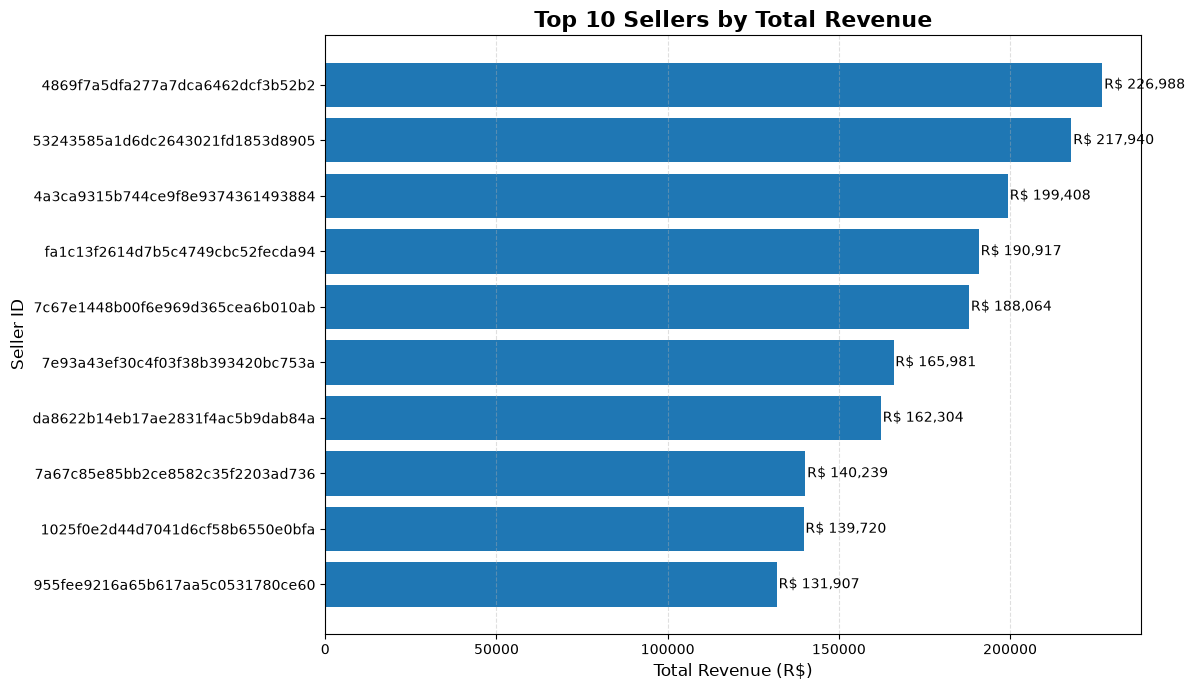

In [26]:
import matplotlib.pyplot as plt

# Top 10 sellers by revenue
top_revenue = (
    sellers_df
    .sort_values(by='total_revenue', ascending=False)
    .head(10)
    .sort_values(by='total_revenue')   # smallest at top, largest at bottom
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_revenue['seller_id'],
    top_revenue['total_revenue']
)

# Add revenue labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 500,
        bar.get_y() + bar.get_height()/2,
        f'R$ {width:,.0f}',
        va='center',
        fontsize=10
    )

plt.title(
    'Top 10 Sellers by Total Revenue',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Total Revenue (R$)', fontsize=12)
plt.ylabel('Seller ID', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

# Save figure
plt.savefig(
    '../reports/top_10_sellers_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Interpretation

The analysis shows that seller revenue is highly concentrated among a relatively small number of sellers. The highest-performing sellers contribute substantially more revenue than the average seller, indicating that Olist relies heavily on a limited group of merchants to generate platform revenue.

This concentration represents both an opportunity and a business risk. High-performing sellers drive platform growth, but excessive dependence on a small number of sellers increases operational risk if those sellers leave the platform or experience performance issues.

In [29]:
high_risk_dependency = sellers_df[(sellers_df['average_review_score'] < 3) & (sellers_df['total_revenue'] > sellers_df['total_revenue'].quantile(0.8))]
print("High-risk dependency sellers with average review score < 3 and total revenue in the top 20%:")
print("Number of high-risk dependency sellers:", high_risk_dependency.shape)
display(high_risk_dependency.sort_values(by='total_revenue', ascending=False))

High-risk dependency sellers with average review score < 3 and total revenue in the top 20%:
Number of high-risk dependency sellers: (11, 4)


,seller_id,total_orders,average_review_score,total_revenue
540,2eb70248d66e0e3ef83659f71b244378,198,2.805128,39115.62
2073,b37c4c02bda3161a7546a4e6d222d5b2,15,1.400000,24075.00
751,40db9e9aa57f7bb151bcda6b0f9bdbb7,12,2.363636,23168.00
2053,b1b3948701c5c72445495bd161b83a4c,14,1.928571,21519.50
323,1ca7077d890b907f89be8c954a02686a,127,2.269841,12474.64
2424,cf8ab1616079e2793aa29d524df01bb1,6,2.500000,9594.00
1928,a49928bcdf77c55c6d6e05e09a9b4ca5,104,2.971154,8646.90
1779,972d0f9cf61b499a4812cf0bfa3ad3c4,86,2.964286,7910.42
2255,c26a2be5b53b7db6b276280da212a779,18,2.722222,7482.00
420,2528744c5ef5d955adc318720a94d2e7,5,2.400000,6245.00


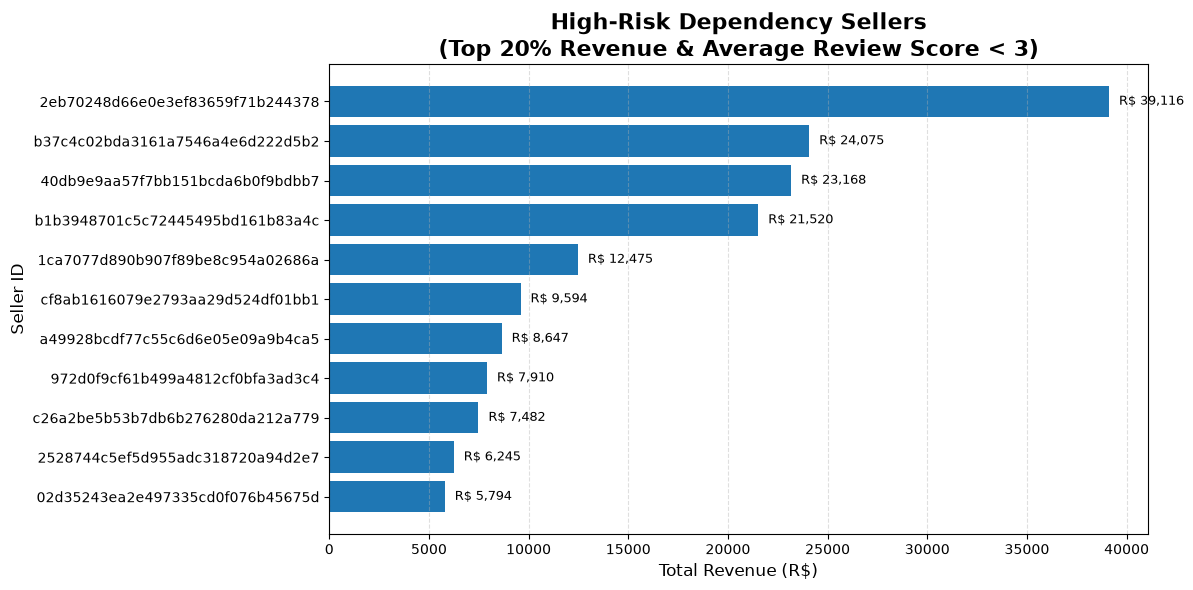

In [28]:
import matplotlib.pyplot as plt

# Sort sellers by revenue (highest first)
risk_sellers = high_risk_dependency.sort_values(
    by='total_revenue',
    ascending=False
)

plt.figure(figsize=(12, max(6, len(risk_sellers) * 0.4)))

bars = plt.barh(
    risk_sellers['seller_id'],
    risk_sellers['total_revenue']
)

# Highest revenue at the top
plt.gca().invert_yaxis()

plt.title(
    'High-Risk Dependency Sellers\n(Top 20% Revenue & Average Review Score < 3)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Total Revenue (R$)', fontsize=12)
plt.ylabel('Seller ID', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)

# Add revenue labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 500,
        bar.get_y() + bar.get_height()/2,
        f'R$ {width:,.0f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()

# Save figure
plt.savefig(
    '../reports/high_risk_dependency_sellers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Interpretation

High-risk dependency sellers were defined as sellers belonging to the top 20% of revenue while maintaining an average review score below 3 stars.

These sellers represent a potential business risk because they contribute significantly to platform revenue while simultaneously generating poor customer experiences. Continued dependence on these sellers may negatively affect customer trust, repeat purchases, and the overall reputation of the marketplace.

These sellers should be prioritized for performance monitoring, operational audits, and quality improvement initiatives.

In [23]:
pareto = sellers_df.sort_values(by='total_revenue', ascending=False).reset_index(drop=True)
pareto['cumulative_revenue'] = pareto['total_revenue'].cumsum()
pareto['cumulative_percentage'] = pareto['cumulative_revenue'] / pareto['total_revenue'].sum() * 100
pareto['cumulative_sellers_percentage'] = (pareto.index + 1) / len(pareto) * 100
display(pareto.head(10))

,seller_id,total_orders,average_review_score,total_revenue,cumulative_revenue,cumulative_percentage,cumulative_sellers_percentage
0,4869f7a5dfa277a7dca6462dcf3b52b2,1148,4.139474,226987.93,226987.93,1.709267,0.03367
1,53243585a1d6dc2643021fd1853d8905,400,4.128141,217940.44,444928.37,3.350405,0.06734
2,4a3ca9315b744ce9f8e9374361493884,1971,3.828630,199408.32,644336.69,4.851993,0.10101
3,fa1c13f2614d7b5c4749cbc52fecda94,579,4.373913,190917.14,835253.83,6.289639,0.13468
4,7c67e1448b00f6e969d365cea6b010ab,1366,3.354197,188063.83,1023317.66,7.705800,0.16835
5,7e93a43ef30c4f03f38b393420bc753a,322,4.364486,165981.49,1189299.15,8.955676,0.20202
6,da8622b14eb17ae2831f4ac5b9dab84a,1571,4.075399,162303.67,1351602.82,10.177857,0.23569
7,7a67c85e85bb2ce8582c35f2203ad736,1159,4.268462,140238.65,1491841.47,11.233884,0.26936
8,1025f0e2d44d7041d6cf58b6550e0bfa,1434,3.867792,139720.16,1631561.63,12.286007,0.30303
9,955fee9216a65b617aa5c0531780ce60,1474,4.089481,131906.71,1763468.34,13.279292,0.33670


In [24]:
pareto_80 = pareto[pareto['cumulative_percentage'] >= 80].iloc[0]

print(f"80% of revenue is generated by approximately {pareto_80['cumulative_sellers_percentage']:.2f}% of sellers.")

80% of revenue is generated by approximately 17.95% of sellers.


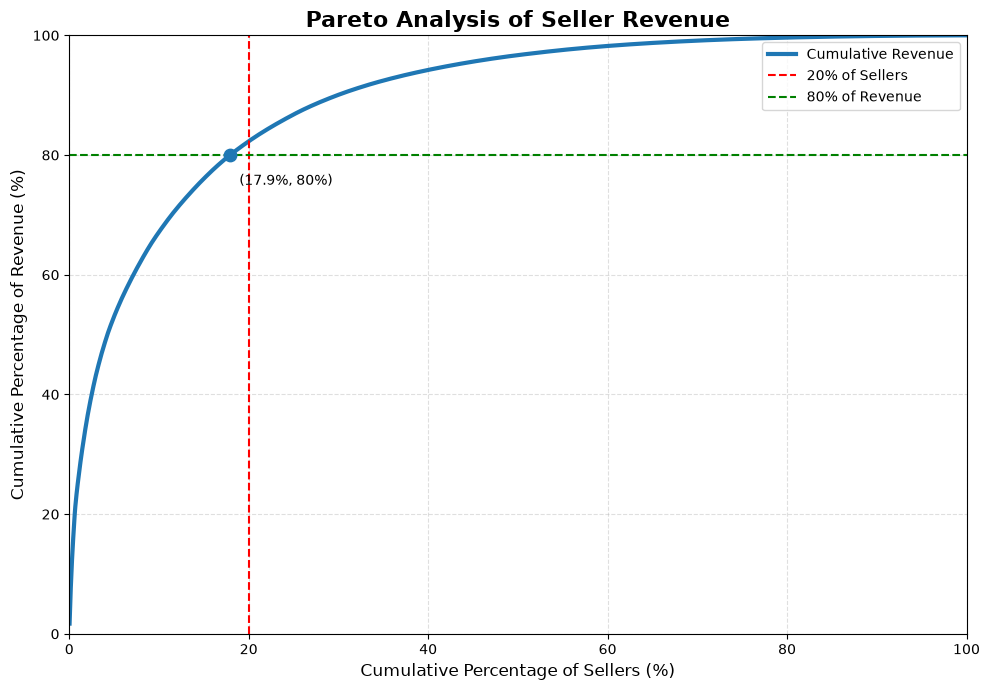

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Cumulative revenue curve
plt.plot(
    pareto['cumulative_sellers_percentage'],
    pareto['cumulative_percentage'],
    linewidth=3,
    label='Cumulative Revenue'
)

# Reference lines
plt.axvline(
    x=20,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='20% of Sellers'
)

plt.axhline(
    y=80,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label='80% of Revenue'
)

# Highlight the intersection
plt.scatter(
    pareto_80['cumulative_sellers_percentage'],
    pareto_80['cumulative_percentage'],
    s=80,
    zorder=5
)

plt.text(
    pareto_80['cumulative_sellers_percentage'] + 1,
    pareto_80['cumulative_percentage'] - 5,
    f"({pareto_80['cumulative_sellers_percentage']:.1f}%, "
    f"{pareto_80['cumulative_percentage']:.0f}%)",
    fontsize=10
)

plt.title(
    'Pareto Analysis of Seller Revenue',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Cumulative Percentage of Sellers (%)', fontsize=12)
plt.ylabel('Cumulative Percentage of Revenue (%)', fontsize=12)

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend()

plt.tight_layout()

plt.savefig(
    '../reports/pareto_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Interpretation

The Pareto analysis was performed to evaluate whether a small proportion of sellers contributes a disproportionately large share of total revenue.

Sellers were ranked from highest to lowest revenue, after which cumulative revenue and cumulative seller percentages were calculated. This approach makes it possible to determine what proportion of sellers generates approximately 80% of platform revenue.

If approximately 20% of sellers account for around 80% of total revenue, the marketplace follows the Pareto Principle. Otherwise, revenue is either more evenly distributed or more heavily concentrated than expected.

## Executive Summary

### Business Objective

The objective of this analysis was to evaluate seller performance across the Olist marketplace by identifying the sellers generating the greatest revenue, assessing seller quality through customer review scores, examining the relationship between seller size and customer satisfaction, and determining whether platform revenue is concentrated among a small number of sellers.

---

### Key Findings

The seller-level analysis confirms that revenue is unevenly distributed across the marketplace. A relatively small group of sellers contributes a disproportionately large share of total platform revenue, supporting Daniel's hypothesis that the marketplace depends heavily on a limited number of high-performing sellers. This concentration presents a significant opportunity for growth but also exposes the business to operational risk should these key sellers experience performance issues or leave the platform.

The analysis of customer review scores revealed considerable variation in seller quality. While many sellers maintain consistently high ratings, several sellers receive substantially lower customer reviews, indicating recurring issues that may involve product quality, fulfillment reliability, or customer service. Sellers with consistently poor ratings and a meaningful order volume should be considered priorities for operational review because they have a greater impact on the overall customer experience than low-volume sellers with only a handful of reviews.

The relationship between seller size and customer satisfaction appears relatively weak. The scatter plot demonstrates that both high-volume and low-volume sellers can achieve either strong or poor customer ratings. This suggests that increasing sales volume does not automatically result in declining service quality, nor does seller size guarantee customer satisfaction. Instead, seller performance is likely influenced by operational efficiency, logistics, product quality, and customer support.

One of the most important findings is the identification of **high-risk dependency sellers**. These sellers belong to the highest revenue segment while simultaneously maintaining average customer review scores below three stars. Although they contribute significantly to marketplace revenue, their consistently poor customer satisfaction presents a strategic business risk. Continued dependence on these sellers may negatively affect customer trust, platform reputation, and long-term customer retention. Olist should closely monitor these sellers, investigate the causes of poor reviews, and implement performance improvement initiatives where necessary.

The Pareto analysis further supports the hypothesis that marketplace revenue is concentrated among a relatively small proportion of sellers. By calculating cumulative seller percentages alongside cumulative revenue, the analysis evaluates whether approximately 20% of sellers generate around 80% of total revenue. This provides management with a clear understanding of revenue concentration and highlights the importance of balancing seller acquisition with seller quality management.

---

### Business Recommendations

- Continue strengthening relationships with high-performing sellers while reducing excessive dependence on a small number of merchants.
- Closely monitor high-revenue sellers with poor customer ratings and introduce performance improvement programs where necessary.
- Establish minimum quality standards for sellers generating significant revenue to protect customer satisfaction and brand reputation.
- Conduct further analysis incorporating delivery performance, product categories, and seller location to better understand the operational factors driving seller performance.
- Regularly monitor revenue concentration using Pareto analysis to ensure marketplace growth remains diversified rather than overly dependent on a limited number of sellers.

---

### Conclusion

The analysis demonstrates that seller performance cannot be evaluated using revenue alone. Although a relatively small number of sellers generates a significant share of marketplace revenue, maintaining customer satisfaction is equally important for sustainable growth. High-revenue sellers with consistently poor customer ratings represent a strategic risk that should be addressed proactively. Balancing revenue generation with seller quality will enable Olist to improve customer experience while reducing operational and reputational risk.